In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [3]:
#load data
data = pd.read_csv("linear_data.csv")
data

,area_sqft,bedrooms,house_age_years,distance_to_city_km,price
0,812,3,24,16.25,209660.43
1,3209,2,20,23.27,608450.83
2,2791,2,28,11.68,527459.85
3,2036,2,29,17.83,400156.94
4,2015,3,21,29.00,377564.82
...,...,...,...,...,...
1495,2010,4,19,21.65,427390.82
1496,2429,2,10,7.88,476554.62
1497,3232,2,12,26.35,614286.67
1498,2135,3,7,9.63,453956.17


In [7]:
# It give the shape of data
data.shape

(1500, 5)

In [5]:
# It give the information of data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   area_sqft            1500 non-null   int64  
 1   bedrooms             1500 non-null   int64  
 2   house_age_years      1500 non-null   int64  
 3   distance_to_city_km  1500 non-null   float64
 4   price                1500 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 58.7 KB


In [6]:
# It give the any rows are empty are not if empty it give the how many rows are empty
data.isnull().sum()

area_sqft              0
bedrooms               0
house_age_years        0
distance_to_city_km    0
price                  0
dtype: int64

In [8]:
# It give the top data
data.head()

,area_sqft,bedrooms,house_age_years,distance_to_city_km,price
0,812,3,24,16.25,209660.43
1,3209,2,20,23.27,608450.83
2,2791,2,28,11.68,527459.85
3,2036,2,29,17.83,400156.94
4,2015,3,21,29.00,377564.82


<Axes: xlabel='area_sqft', ylabel='price'>

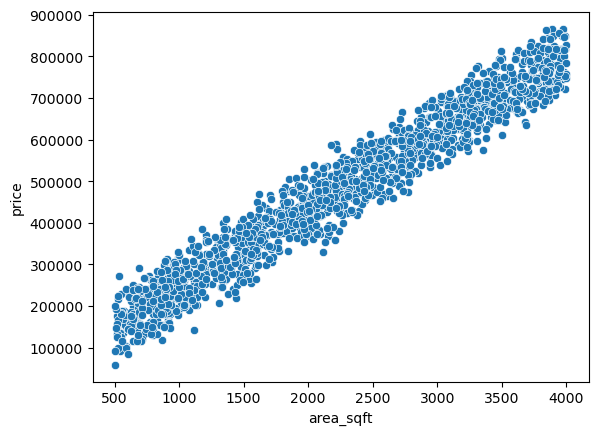

In [11]:
# visualize the data
sns.scatterplot(x="area_sqft",y="price",data=data)

In [12]:
# In x we have input values(independent variabel) that's why we are deleting the price column 
x=data.drop("price",axis=1)
# In y we have only output values(dependent variabel)
y=data["price"]

In [13]:
x

,area_sqft,bedrooms,house_age_years,distance_to_city_km
0,812,3,24,16.25
1,3209,2,20,23.27
2,2791,2,28,11.68
3,2036,2,29,17.83
4,2015,3,21,29.00
...,...,...,...,...
1495,2010,4,19,21.65
1496,2429,2,10,7.88
1497,3232,2,12,26.35
1498,2135,3,7,9.63


In [14]:
y

0       209660.43
1       608450.83
2       527459.85
3       400156.94
4       377564.82
          ...    
1495    427390.82
1496    476554.62
1497    614286.67
1498    453956.17
1499    779393.07
Name: price, Length: 1500, dtype: float64

In [15]:
# Create train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [16]:
# Train linear regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
model.intercept_

np.float64(48661.11042831652)

In [19]:
model.coef_

array([  185.6199455 , 22039.29869086,  -884.78452867, -2569.73764189])

In [20]:
data.head(1)

,area_sqft,bedrooms,house_age_years,distance_to_city_km,price
0,812,3,24,16.25,209660.43


In [23]:
y_pred = model.predict(x_test)

In [24]:
# It gives the goodness of model
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9914902463561405

In [27]:
# It gives the how bad the model
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error
print("Mean_squared_Error :- ",mean_squared_error(y_test,y_pred))
print("Mean_Absolute_Error :- ",mean_absolute_error(y_test,y_pred))
print("Root_Mean_Squared_Error :- ",root_mean_squared_error(y_test,y_pred))


Mean_squared_Error :-  302453437.54978645
Mean_Absolute_Error :-  13717.445958065427
Root_Mean_Squared_Error :-  17391.18850308358
